<a href="https://colab.research.google.com/github/Akshitha94127/NASSCOM/blob/main/Copy_of_U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# 1A. NUMERICAL vs CATEGORICAL COLUMNS
print(df.dtypes)
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [ ]:
# 1B. WHICH STATISTIC FITS WHICH TYPE
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [ ]:
# LAB EXERCISE 1 — Classify the columns
import pandas as pd
import seaborn as sns
df = sns.load_dataset('tips')
# 1.
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
# 2.
tip_mean = df['tip'].mean()
print(f"\nMean of 'tip': {tip_mean:.4f}")
# 3.
sex_counts = df['sex'].value_counts()
print("\nValue counts of 'sex':")
print(sex_counts)

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']

Mean of 'tip': 2.9983

Value counts of 'sex':
sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
# 2A. MEAN, MEDIAN, MODE
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


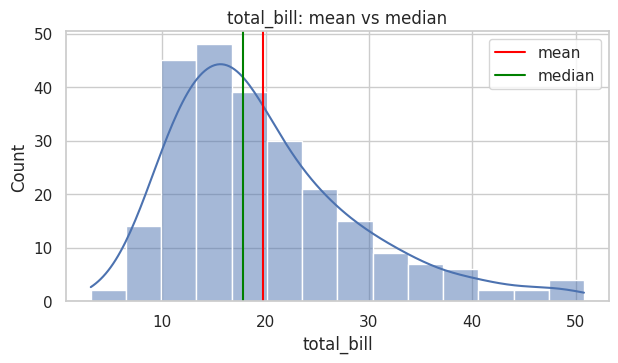

In [ ]:
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')
plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean:   2.9983
Median: 2.9000
Mode:   2.0000
Is mean > median? True (Confirms Right-Skewness)


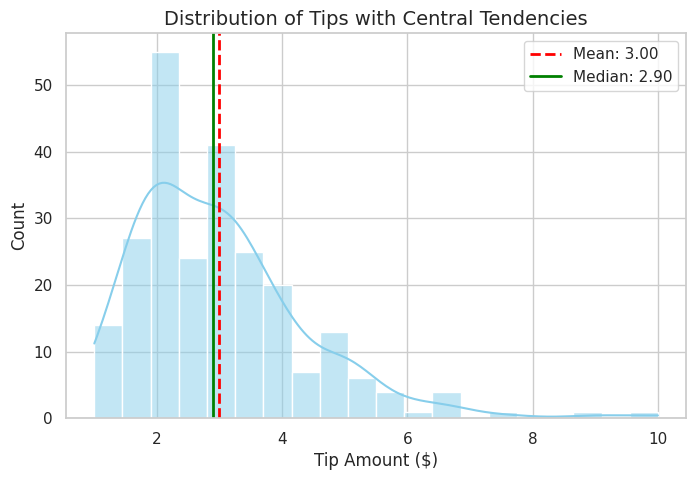

In [ ]:
# LAB EXERCISE 2 — Central tendency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset('tips')
tip = df['tip']
# 1.
tip_mean = tip.mean()
tip_median = tip.median()
tip_mode = tip.mode()[0]
print(f"Mean:   {tip_mean:.4f}")
print(f"Median: {tip_median:.4f}")
print(f"Mode:   {tip_mode:.4f}")
# 2.
is_right_skewed = tip_mean > tip_median
print(f"Is mean > median? {is_right_skewed} (Confirms Right-Skewness)")
# 3.
plt.figure(figsize=(8, 5))
sns.histplot(tip, kde=True, color='skyblue', bins=20)
plt.axvline(tip_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {tip_mean:.2f}')
plt.axvline(tip_median, color='green', linestyle='-', linewidth=2, label=f'Median: {tip_median:.2f}')
plt.title('Distribution of Tips with Central Tendencies', fontsize=14)
plt.xlabel('Tip Amount ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

In [ ]:
# 3A. RANGE, VARIANCE, STANDARD DEVIATION
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [ ]:
# 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [ ]:
# LAB EXERCISE 3 — Spread
import pandas as pd
import seaborn as sns
df = sns.load_dataset('tips')
tip = df['tip']
# 1.
tip_range = tip.max() - tip.min()
tip_variance = tip.var()
tip_std = tip.std()
print(f"Range:              {tip_range:.4f}")
print(f"Variance:           {tip_variance:.4f}")
print(f"Standard Deviation: {tip_std:.4f}")
# 2.
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1
print(f"\nQ1 (25th percentile): {Q1:.4f}")
print(f"Q3 (75th percentile): {Q3:.4f}")
print(f"IQR (Interquartile):  {IQR:.4f}")
# 3.

Range:              9.0000
Variance:           1.9145
Standard Deviation: 1.3836

Q1 (25th percentile): 2.0000
Q3 (75th percentile): 3.5625
IQR (Interquartile):  1.5625


In [ ]:
# 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


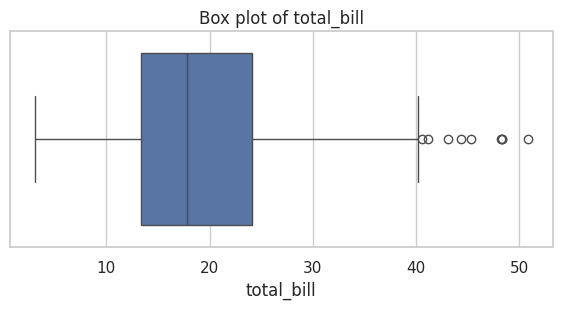

In [ ]:
# 4B. BOX PLOT (a picture of the five-number summary)
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

Five-Number Summary:
Min: 1.0000
25% (Q1): 2.0000
50% (Median): 2.9000
75% (Q3): 3.5625
Max: 10.0000

Skewness: 1.4655


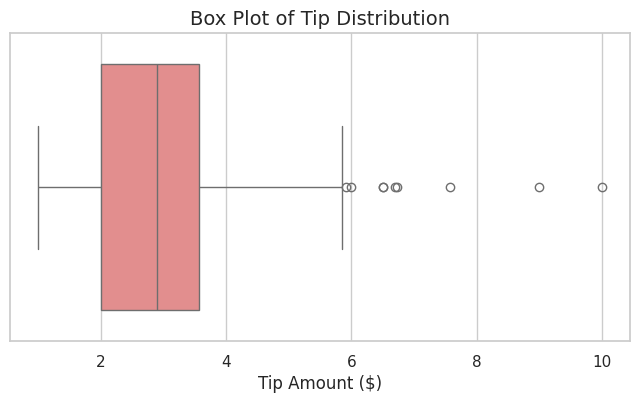

In [ ]:
# LAB EXERCISE 4 — Five-number summary & box plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('tips')
tip = df['tip']
# 1.
five_num = tip.describe()
print("Five-Number Summary:")
print(f"Min: {five_num['min']:.4f}")
print(f"25% (Q1): {five_num['25%']:.4f}")
print(f"50% (Median): {five_num['50%']:.4f}")
print(f"75% (Q3): {five_num['75%']:.4f}")
print(f"Max: {five_num['max']:.4f}")
# 2.
tip_skew = tip.skew()
print(f"\nSkewness: {tip_skew:.4f}")
# 3.
plt.figure(figsize=(8, 4))
sns.boxplot(x=tip, color='lightcoral')
plt.title('Box Plot of Tip Distribution', fontsize=14)
plt.xlabel('Tip Amount ($)', fontsize=12)
plt.show()

In [ ]:
# 5A. CORRELATION between numerical columns
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


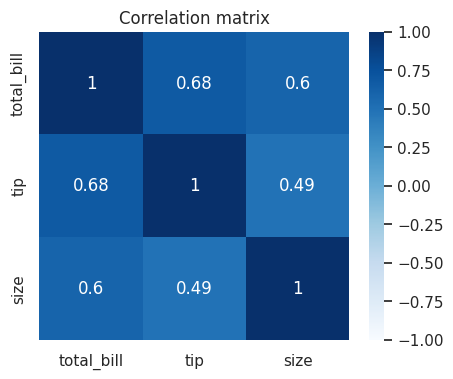

In [ ]:
# 5B. VISUALISE THE CORRELATION MATRIX
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [ ]:
# 5C. ONE-SHOT SUMMARY with .describe()
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


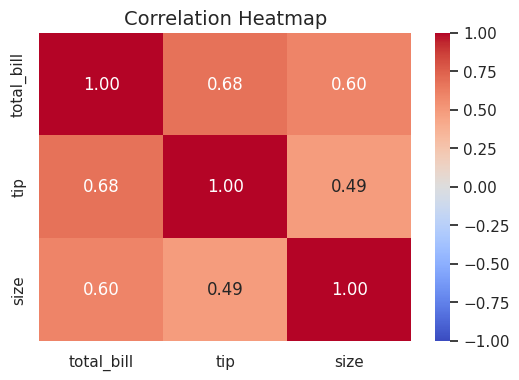


Dataset Summary Statistics:
        total_bill         tip   sex smoker  day    time        size
count   244.000000  244.000000   244    244  244     244  244.000000
unique         NaN         NaN     2      2    4       2         NaN
top            NaN         NaN  Male     No  Sat  Dinner         NaN
freq           NaN         NaN   157    151   87     176         NaN
mean     19.785943    2.998279   NaN    NaN  NaN     NaN    2.569672
std       8.902412    1.383638   NaN    NaN  NaN     NaN    0.951100
min       3.070000    1.000000   NaN    NaN  NaN     NaN    1.000000
25%      13.347500    2.000000   NaN    NaN  NaN     NaN    2.000000
50%      17.795000    2.900000   NaN    NaN  NaN     NaN    2.000000
75%      24.127500    3.562500   NaN    NaN  NaN     NaN    3.000000
max      50.810000   10.000000   NaN    NaN  NaN     NaN    6.000000


In [ ]:
# LAB EXERCISE 5 — Correlation & full summary
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('tips')
# 1.
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
print("Correlation Matrix:")
print(corr_matrix.round(2))
# 2.
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()
# 3.
print("\nDataset Summary Statistics:")
print(df.describe(include='all'))